# Price Prediction - Optimized

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.model_selection import KFold
cv_strategy = KFold(shuffle=True, random_state=42)
encoder = TargetEncoder(cv=cv_strategy)

df = pd.read_csv("../../data/processed/cleaned_listings.csv")
df["description"] = df["description"].fillna("")
desc = df["description"].str.lower()
for name, kw in {"desc_has_metro":"metro","desc_has_luxury":"luxury","desc_has_premium":"premium",
                  "desc_has_gated":"gated","desc_has_corner_plot":"corner plot","desc_has_spacious":"spacious"}.items():
    df[name] = desc.str.contains(kw, regex=False).astype(int)
df["log_price"] = np.log1p(df["price"])


## Feature Setup

In [2]:
desc_cols = [c for c in df.columns if c.startswith("desc_has_")]
onehot_cols = ["city", "property_type", "facing", "status"]
target_enc_cols = ["location"]
numeric_cols = ["area", "security_deposit", "age of property", "locality_score", "amenity_count",
                "new/resale", "price_negotiable", "furnished", "Car Parking",
                "Lift(s)","Full Power Backup","24 X 7 Security","Children's play area",
                "Club House","Gymnasium","Swimming Pool","Sports Facility",
                "Jogging Track","Landscaped Gardens"] + desc_cols

X = df[onehot_cols + target_enc_cols + numeric_cols]
y_log, y_price = df["log_price"], df["price"]
X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(X, y_log, y_price, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), onehot_cols),
    ("target_enc", TargetEncoder(target_type="continuous", random_state=42), target_enc_cols),
    ("scale", StandardScaler(), numeric_cols),
])

def make_pipeline(model):
    return Pipeline([("prep", preprocessor), ("model", model)])

log_min, log_max = y_train.min(), y_train.max()


## Baseline from Original Notebook

In [3]:
prev_model = joblib.load("../../models/price_model.pkl")
prev_scaler = joblib.load("../../models/price_scaler.pkl")
prev_cols = joblib.load("../../models/price_model_columns.pkl")
prev_num_cols = joblib.load("../../models/price_numeric_columns.pkl")
prev_loc_enc = joblib.load("../../models/price_location_encoding.pkl")
prev_global_mean = joblib.load("../../models/price_location_global_mean.pkl")
prev_log_min, prev_log_max = joblib.load("../../models/price_log_clip_range.pkl")

cat_cols_prev = ["city", "property_type", "facing", "status"]
X_prev = pd.get_dummies(df.drop(columns=["description","price_currency","price_per_sqft","log_price"]),
                         columns=cat_cols_prev, drop_first=True)
X_prev_test = X_prev.loc[X_test.index].copy()
X_prev_test["location_encoded"] = X_prev_test["location"].map(prev_loc_enc).fillna(prev_global_mean)
X_prev_test = X_prev_test.drop(columns=["location"])
X_prev_test[prev_num_cols] = prev_scaler.transform(X_prev_test[prev_num_cols])
X_prev_test = X_prev_test.reindex(columns=prev_cols, fill_value=0)

prev_pred = np.expm1(np.clip(prev_model.predict(X_prev_test), prev_log_min, prev_log_max))
prev_r2 = r2_score(price_test, prev_pred)
print(f"Original Best (price_prediction_model.ipynb): R2={prev_r2:.3f}")


Original Best (price_prediction_model.ipynb): R2=0.820


## Model Selection - 5-Fold CV

Ridge: CV R2 = 0.803 +/- 0.008
Random Forest: CV R2 = 0.899 +/- 0.009
HistGradientBoosting: CV R2 = 0.906 +/- 0.008


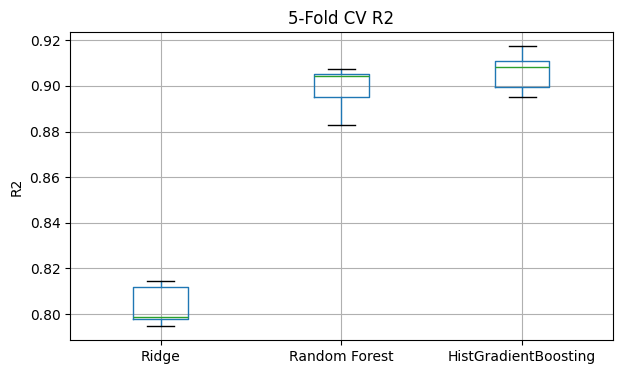

In [4]:
candidates = {
    "Ridge": make_pipeline(Ridge(alpha=1.0)),
    "Random Forest": make_pipeline(RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)),
    "HistGradientBoosting": make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=42)),
}

cv_results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    cv_results[name] = scores
    print(f"{name}: CV R2 = {scores.mean():.3f} +/- {scores.std():.3f}")

pd.DataFrame(cv_results).boxplot(figsize=(7,4))
plt.title("5-Fold CV R2"); plt.ylabel("R2"); plt.show()


## Held-Out Test

In [5]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_pipe = candidates[best_name]
best_pipe.fit(X_train, y_train)
pred_price = np.expm1(np.clip(best_pipe.predict(X_test), log_min, log_max))
new_r2 = r2_score(price_test, pred_price)
print(f"{best_name} held-out test R2={new_r2:.3f}")
print(f"Original: R2={prev_r2:.3f}  |  New: R2={new_r2:.3f}")


HistGradientBoosting held-out test R2=0.857
Original: R2=0.820  |  New: R2=0.857


## Feature Importance

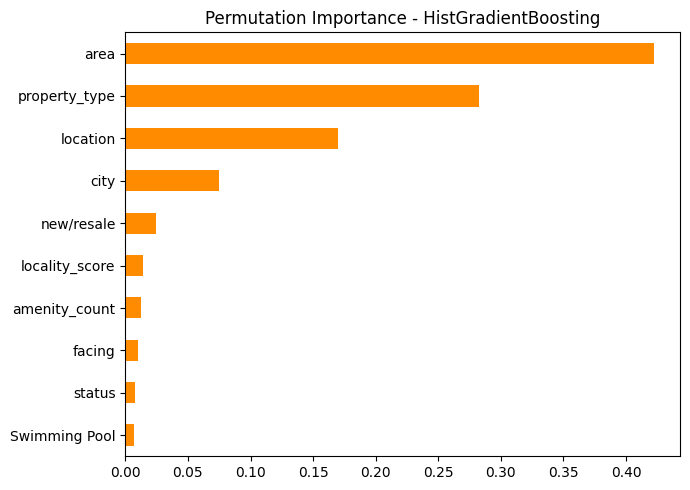

In [6]:
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=5, random_state=42, scoring="r2")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind="barh", figsize=(7,5), color="darkorange")
plt.title(f"Permutation Importance - {best_name}"); plt.tight_layout(); plt.show()


## Quantile Regression

In [7]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    pipe_q = make_pipeline(HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=200, random_state=42))
    pipe_q.fit(X_train, y_train)
    quantile_models[q] = pipe_q

sample = X_test.sample(8, random_state=1)
sample_actual = np.expm1(y_test.loc[sample.index])
preds = {q: np.expm1(np.clip(m.predict(sample), log_min, log_max)) for q, m in quantile_models.items()}
interval_df = pd.DataFrame({"Actual": sample_actual.values, "P10": preds[0.1],
                             "P50": preds[0.5], "P90": preds[0.9]}).round(0)
interval_df


,Actual,P10,P50,P90
0,5800000.0,2757713.0,3490907.0,4425097.0
1,6700000.0,5248739.0,6253790.0,7132236.0
2,3500000.0,1958551.0,2417984.0,2891258.0
3,999000.0,468172.0,999019.0,1081168.0
4,2700000.0,2643951.0,3242053.0,3972725.0
5,8123052.0,7235283.0,8595815.0,9839276.0
6,660000.0,655733.0,1423519.0,3157815.0
7,8000000.0,4475920.0,5797383.0,8910831.0


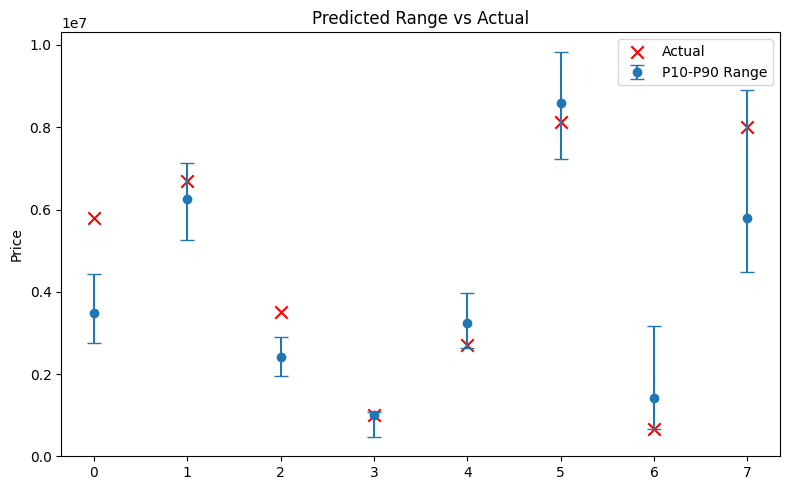

In [8]:
plt.figure(figsize=(8,5))
x_pos = np.arange(len(interval_df))
plt.errorbar(x_pos, interval_df["P50"],
             yerr=[interval_df["P50"]-interval_df["P10"], interval_df["P90"]-interval_df["P50"]],
             fmt="o", capsize=5, label="P10-P90 Range")
plt.scatter(x_pos, interval_df["Actual"], color="red", marker="x", s=80, label="Actual")
plt.xticks(x_pos); plt.ylabel("Price"); plt.legend(); plt.title("Predicted Range vs Actual")
plt.tight_layout(); plt.show()


## Save

In [9]:
if new_r2 > prev_r2:
    joblib.dump(best_pipe, "../../models/price_model_pipeline_v2.pkl")
    joblib.dump((log_min, log_max), "../../models/price_log_clip_range_v2.pkl")
    joblib.dump(quantile_models, "../../models/price_quantile_models_v2.pkl")
    print(f"Saved new model ({best_name}) as price_model_pipeline_v2.pkl - improved R2 {prev_r2:.3f} -> {new_r2:.3f}")
else:
    print(f"Original model kept - new R2 {new_r2:.3f} did not beat {prev_r2:.3f}")


Saved new model (HistGradientBoosting) as price_model_pipeline_v2.pkl - improved R2 0.820 -> 0.857
